# Fuzzy Control System: Grocery Reordering (Stock Level × Sales Rate → Reorder Urgency)


# Creating the Grocery Reorder Controller Using the `skfuzzy` Control API`

/Users/ksv/Desktop/University_Of_Bern/Semester-4/Teaching units/Fuzzy systems/fuzzy-tutorial-main/venv/lib/python3.12/site-packages/skfuzzy/control/term.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


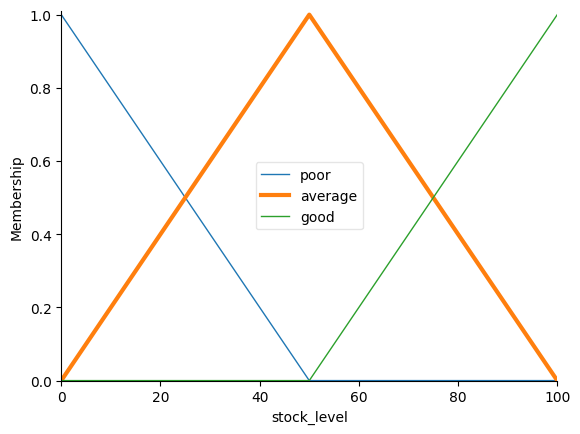

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# New Antecedent/Consequent objects hold universe variables and membership functions
# Inputs scaled to 0–100 so you can plug in percent/percentile features later.
stock_level = ctrl.Antecedent(np.arange(0, 101, 1), 'stock_level')   # 0 = empty, 100 = full
sales_rate  = ctrl.Antecedent(np.arange(0, 101, 1), 'sales_rate')    # 0 = very slow, 100 = very fast
reorder_urgency = ctrl.Consequent(np.arange(0, 101, 1), 'reorder_urgency')  # 0 = no rush, 100 = urgent

# Auto-membership function population (keeps labels: 'poor', 'average', 'good')
stock_level.automf(3)
sales_rate.automf(3)

# Custom membership functions for the output (urgency)
reorder_urgency['low']    = fuzz.trimf(reorder_urgency.universe, [0, 0, 40])
reorder_urgency['medium'] = fuzz.trimf(reorder_urgency.universe, [20, 50, 80])
reorder_urgency['high']   = fuzz.trimf(reorder_urgency.universe, [60, 100, 100])

# You can see how these look with .view()
stock_level['average'].view()

/Users/ksv/Desktop/University_Of_Bern/Semester-4/Teaching units/Fuzzy systems/fuzzy-tutorial-main/venv/lib/python3.12/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


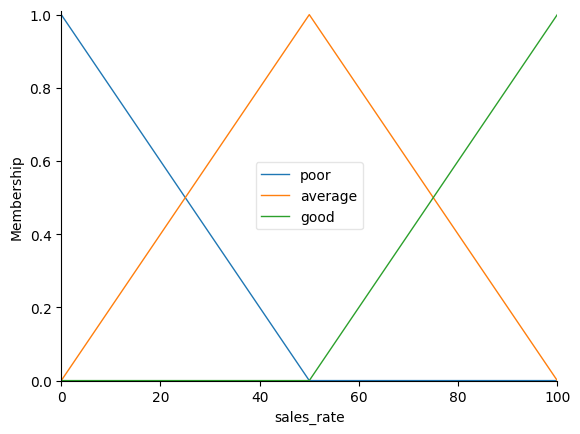

In [2]:
sales_rate.view()


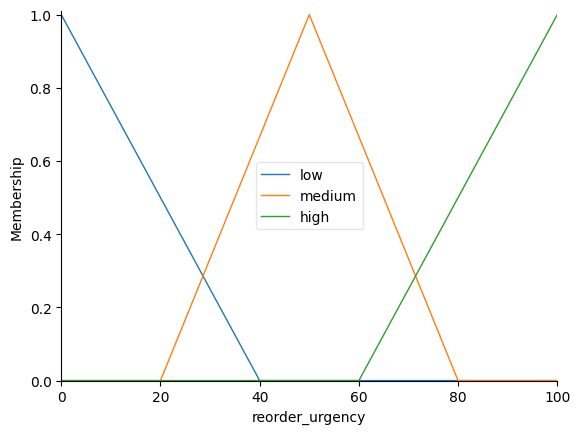

In [3]:
reorder_urgency.view()


# Fuzzy Rules for Grocery Reordering




(<Figure size 640x480 with 1 Axes>, <Axes: >)

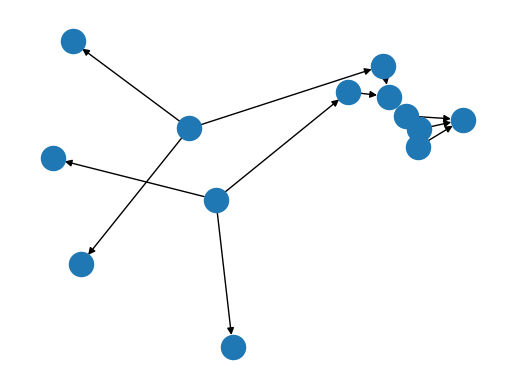

In [4]:

rule1 = ctrl.Rule(stock_level['poor'] | sales_rate['poor'], reorder_urgency['low'])
rule2 = ctrl.Rule(sales_rate['average'], reorder_urgency['medium'])
rule3 = ctrl.Rule(stock_level['poor'] | sales_rate['good'], reorder_urgency['high'])

# Visualize a rule to confirm it’s built correctly
rule1.view()

# Control System Creation and Simulation on Inventory & Sales

Reorder urgency: 51.35


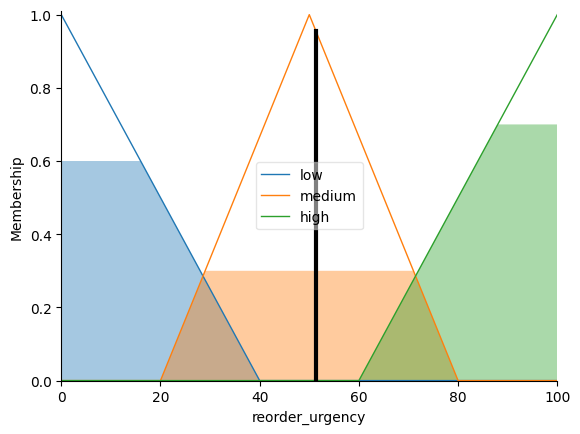

In [5]:
# Build the fuzzy control system for grocery reordering
reorder_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
reorder_sim  = ctrl.ControlSystemSimulation(reorder_ctrl)

# Example simulation — plug in stock level and sales rate (both 0–100)
reorder_sim.input['stock_level'] = 20   # low stock
reorder_sim.input['sales_rate']  = 85   # fast sales

# Compute the fuzzy result
reorder_sim.compute()

# Print and visualize the result
print(f"Reorder urgency: {reorder_sim.output['reorder_urgency']:.2f}")
reorder_urgency.view(sim=reorder_sim)

In order to simulate this grocery reordering control system, we’ll create a ControlSystemSimulation object.
Think of this object as representing our inventory controller applied to a specific product or situation.
For example, one simulation might represent the “Milk” item in your store — with its own stock level and sales rate — while another simulation could represent “Rice” or “Bread”, each with different conditions.
Every time you want to evaluate reorder urgency for a particular product, you create or reuse a ControlSystemSimulation instance, feed in the product’s stock_level and sales_rate, and the system will calculate the appropriate reorder_urgency based on your fuzzy rules.

In [7]:
# Create a simulation instance for the grocery reordering control system
reorder = ctrl.ControlSystemSimulation(reorder_ctrl)

We can now simulate our grocery reordering control system by specifying the current inventory and sales conditions, then calling the .compute() method.
For example, suppose the stock level is 25 % (quite low) and the sales rate is 80 % (selling fast).
The controller will combine these fuzzy inputs to calculate how urgent it is to reorder that item.

Reorder urgency: 51.63


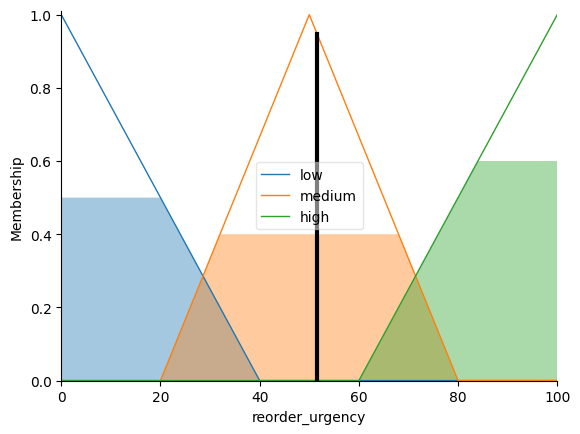

In [8]:

# Pass inputs to the ControlSystem using Antecedent labels with Pythonic API
# Example: simulate one product (e.g., "Milk")
# Note: if you prefer, you can also pass all inputs at once using reorder.inputs({...})
reorder.input['stock_level'] = 25   # 25% of stock remaining (low)
reorder.input['sales_rate']  = 80   # 80% sales rate (selling fast)

# Crunch the numbers
reorder.compute()

# Once computed, we can view the numeric result and visualize it
print(f"Reorder urgency: {reorder.output['reorder_urgency']:.2f}")

# Show how the result fits into the fuzzy membership functions
reorder_urgency.view(sim=reorder)

# Defuzzification: Reorder Urgency (and Reorder Quantity, optional)

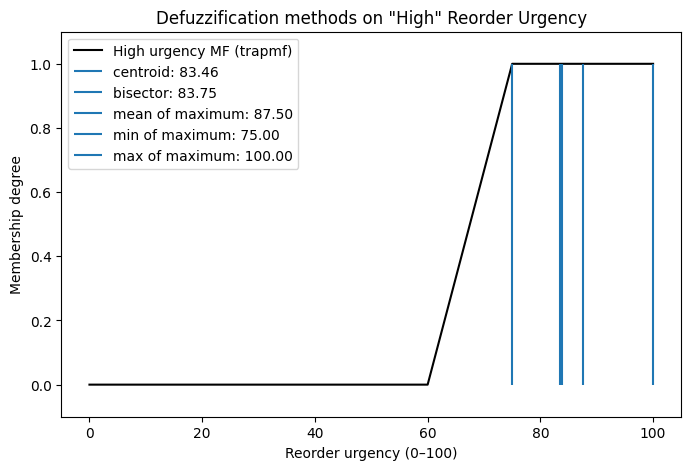

In [9]:
import matplotlib.pyplot as plt

# Universe for reorder_urgency: 0–100 (0 = no rush, 100 = urgent)
x = np.arange(0, 100.5, 0.5)

# Trapezoidal membership for "High" reorder urgency
# Edit the four points to match your controller if needed.
# Example: starts rising at 60, fully high by 75, stays high to 100.
mfx = fuzz.trapmf(x, [60, 75, 100, 100])

# Defuzzify this membership function five ways
defuzz_centroid = fuzz.defuzz(x, mfx, 'centroid')  # Same as skfuzzy.centroid
defuzz_bisector = fuzz.defuzz(x, mfx, 'bisector')
defuzz_mom      = fuzz.defuzz(x, mfx, 'mom')
defuzz_som      = fuzz.defuzz(x, mfx, 'som')
defuzz_lom      = fuzz.defuzz(x, mfx, 'lom')

# Collect info for vertical lines
labels = ['centroid', 'bisector', 'mean of maximum', 'min of maximum', 'max of maximum']
xvals  = [defuzz_centroid, defuzz_bisector, defuzz_mom, defuzz_som, defuzz_lom]
ymax   = [fuzz.interp_membership(x, mfx, xv) for xv in xvals]

# Display and compare defuzzification results against membership function
plt.figure(figsize=(8, 5))
plt.plot(x, mfx, 'k', label='High urgency MF (trapmf)')
for xv, y, label in zip(xvals, ymax, labels):
    plt.vlines(xv, 0, y, label=f'{label}: {xv:.2f}')
plt.ylabel('Membership degree')
plt.xlabel('Reorder urgency (0–100)')
plt.ylim(-0.1, 1.1)
plt.legend(loc='upper left')
plt.title('Defuzzification methods on "High" Reorder Urgency')
plt.show()